# Customer Churn Prediction

This project predicts whether a telecom customer is likely to churn.

## Workflow

1. Load the dataset
2. Explore the data
3. Clean the data
4. Perform exploratory data analysis
5. Prepare features
6. Train machine learning models
7. Evaluate the models
8. Tune the classification threshold
9. Save the best model
10. Test the model on new customers

In [235]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## 1. Load Dataset

In [236]:
import os
# where python is looking at the moment for files
print(os.getcwd())


c:\Users\romis\OneDrive\Desktop\DataScience\Customer_churn\notebooks


In [237]:
df = pd.read_csv("../Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [238]:
df.shape

(7043, 21)

In [239]:
df.columns.to_list()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [240]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [241]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [242]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [243]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [244]:
#doesnt automatically consider empty strings or certain text values as missing
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [245]:
(df == "").sum()
# check for empty strings in the dataset, which can be considered as missing values in some cases.

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [246]:
df["TotalCharges"].value_counts().tail()

TotalCharges
1990.5    1
7362.9    1
346.45    1
306.6     1
6844.5    1
Name: count, dtype: int64

In [247]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors='coerce')

In [248]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

#### Remove missing rows

In [249]:
df=df.dropna(subset=["TotalCharges"])
df.isnull().sum().sum()

np.int64(0)

In [250]:
df.isnull().sum().sum()

np.int64(0)

In [251]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [252]:
# Remove ID BEFORE creating X
df = df.drop(columns=["customerID"])

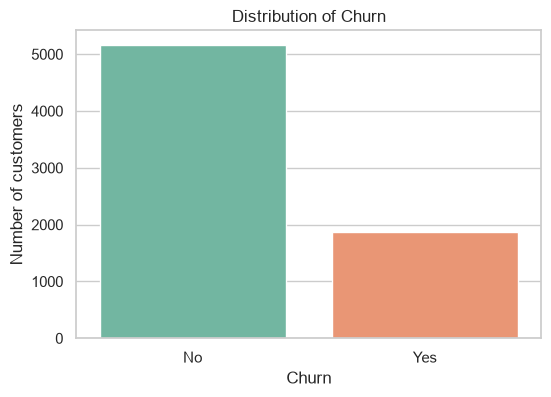

In [253]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn", palette="Set2")

plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Number of customers")

plt.show()

In [254]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100
churn_percentage

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

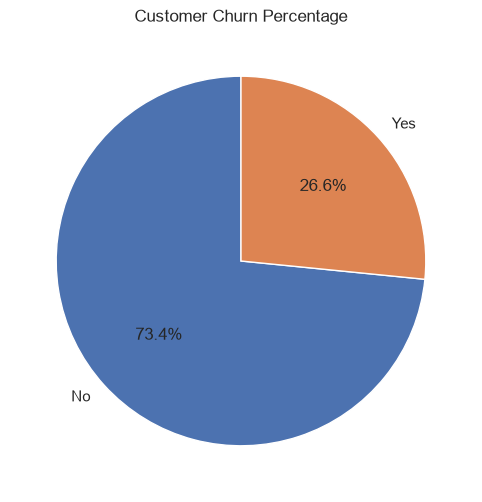

In [255]:
plt.figure(figsize=(6, 6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")
plt.ylabel("")

plt.show()

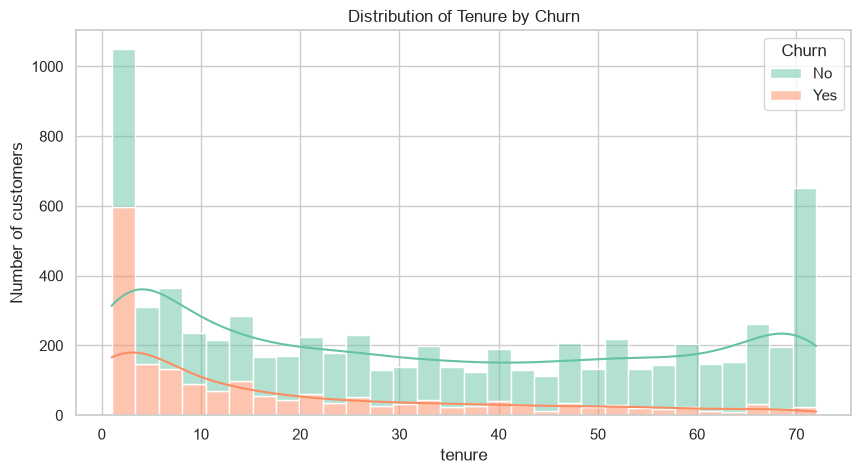

In [256]:
plt.figure(figsize=(10,5))

sns.histplot(data=df, 
             x="tenure",
             hue="Churn", 
             multiple="stack",
             bins=30, 
             kde=True,
             palette="Set2")

plt.title("Distribution of Tenure by Churn")
 
plt.ylabel("Number of customers")
plt.show()

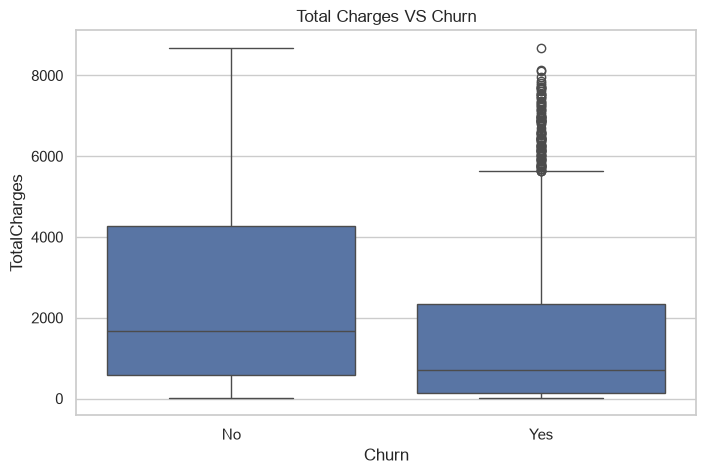

In [257]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="Churn",
            y="TotalCharges")

plt.title("Total Charges VS Churn")
plt.show()

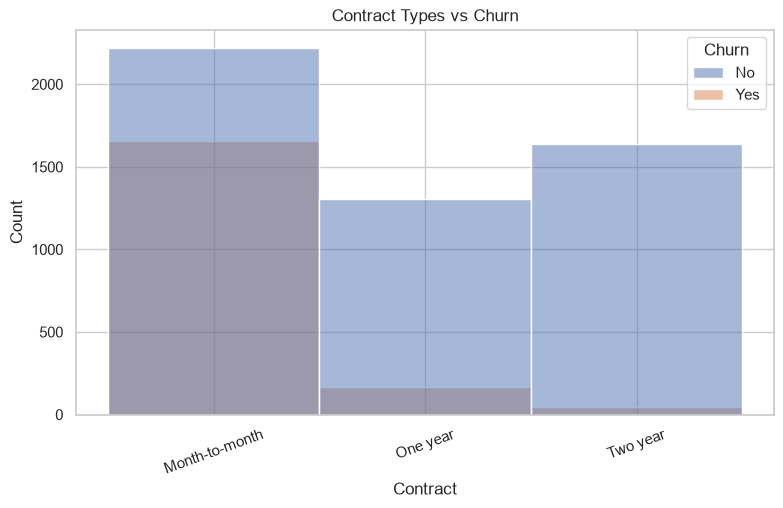

In [258]:
plt.figure(figsize=(9,5))

sns.histplot(data=df,
             x="Contract",
             hue="Churn",
)
plt.title("Contract Types vs Churn")
plt.xticks(rotation=20)
plt.show()

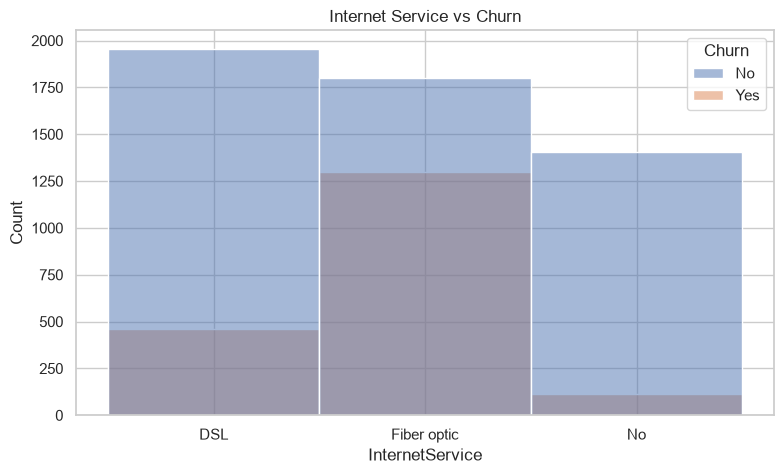

In [259]:
plt.figure(figsize=(9,5))
sns.histplot(data=df,
             x="InternetService",
             hue="Churn",
)
plt.title("Internet Service vs Churn")
plt.show()

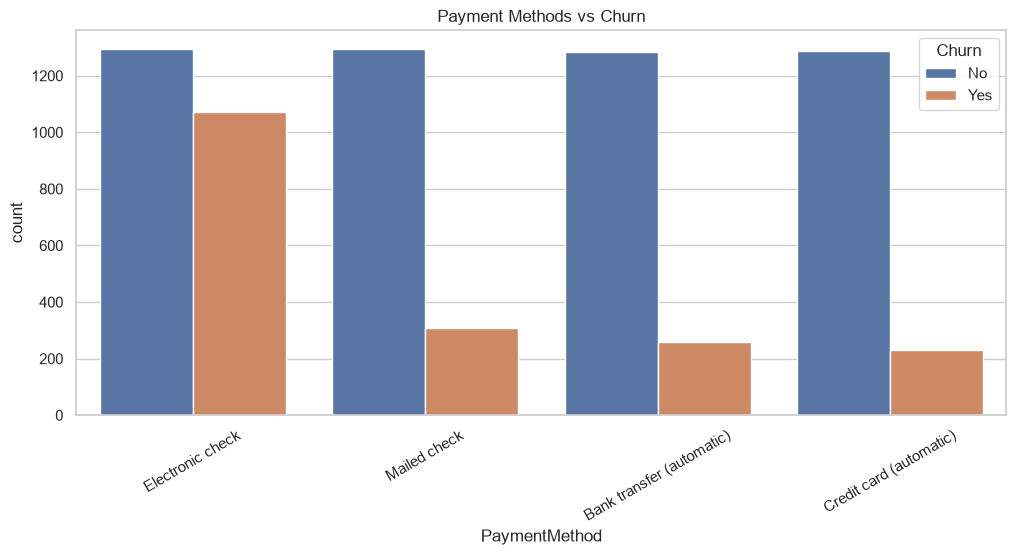

In [260]:
plt.figure(figsize=(12,5))
sns.countplot(data=df,
              x="PaymentMethod",    
              hue="Churn",
)
plt.title("Payment Methods vs Churn")
plt.xticks(rotation=30)
plt.show()

Text(0.5, 1.0, 'Senior Citizen vs Churn')

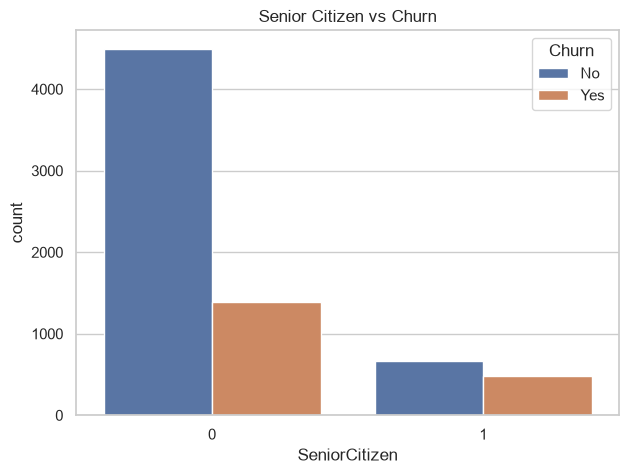

In [261]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,
              x="SeniorCitizen",
              hue="Churn",
)
plt.title("Senior Citizen vs Churn")


In [262]:
df["ChurnNumeric"]=df["Churn"].map({"Yes": 1, "No": 0})

In [263]:
numerical_df= df[[
    "SeniorCitizen", 
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ChurnNumeric"
    
]]
numerical_df.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChurnNumeric
SeniorCitizen,1.000000,0.015683,0.219874,0.102411,0.150541
tenure,0.015683,1.000000,0.246862,0.825880,-0.354049
MonthlyCharges,0.219874,0.246862,1.000000,0.651065,0.192858
TotalCharges,0.102411,0.825880,0.651065,1.000000,-0.199484
ChurnNumeric,0.150541,-0.354049,0.192858,-0.199484,1.000000


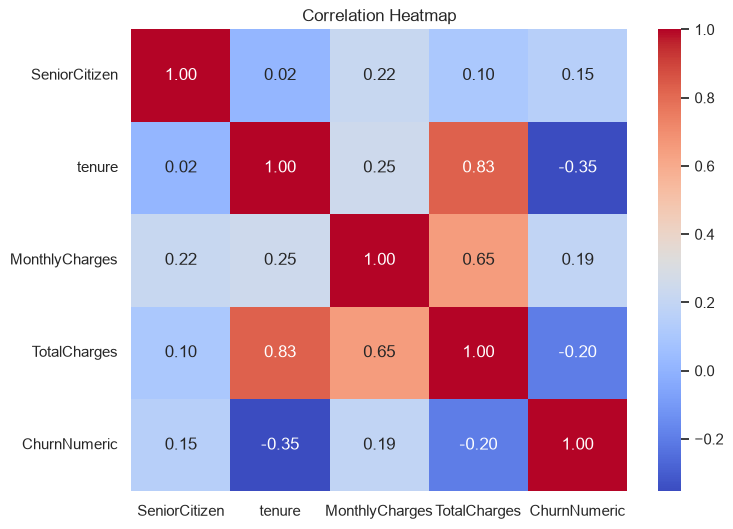

In [264]:
plt.figure(figsize=(8,6))

sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [265]:
df.drop(columns=["ChurnNumeric"],
        inplace=True
        )


In [266]:

print(df.columns.tolist())


['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [267]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [268]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [269]:
X=df.drop(columns=["Churn"])
y=df["Churn"]

In [270]:
X.shape, y.shape

((7032, 19), (7032,))

In [271]:
numerical_features = ["SeniorCitizen", 
                      "tenure",
                      "MonthlyCharges", 
                      "TotalCharges"]

In [272]:
categorical_features = [
    column
    for column in X.columns
    if column not in numerical_features
]
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [273]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [274]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5625
Testing samples: 1407


In [275]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [276]:
print(X.columns.to_list())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [277]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

In [278]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [279]:
logistic_predictions = logistic_model.predict(X_test)

In [280]:
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

In [281]:
def evaluate_model(
    model_name,
    y_true,
    predictions,
    probabilities
):

    accuracy = accuracy_score(
        y_true,
        predictions
    )

    precision = precision_score(
        y_true,
        predictions
    )

    recall = recall_score(
        y_true,
        predictions
    )

    f1 = f1_score(
        y_true,
        predictions
    )

    roc_auc = roc_auc_score(
        y_true,
        probabilities
    )

    print(f"\n===== {model_name} =====")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    }

In [282]:
logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_predictions,
    logistic_probabilities
)


===== Logistic Regression =====
Accuracy : 0.7257
Precision: 0.4901
Recall   : 0.7968
F1 Score : 0.6069
ROC-AUC  : 0.8351


In [283]:
print (
    classification_report(
        y_test,
        logistic_predictions,
    )
)

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



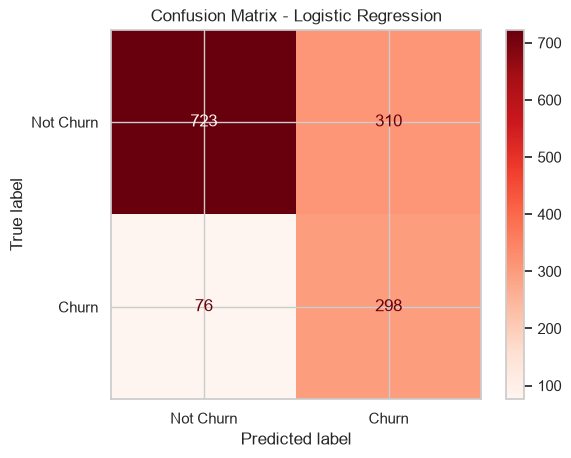

In [284]:
cm=confusion_matrix(
    y_test,
    logistic_predictions
)

disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Churn", "Churn"]
    
)

disp.plot(cmap="Reds")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

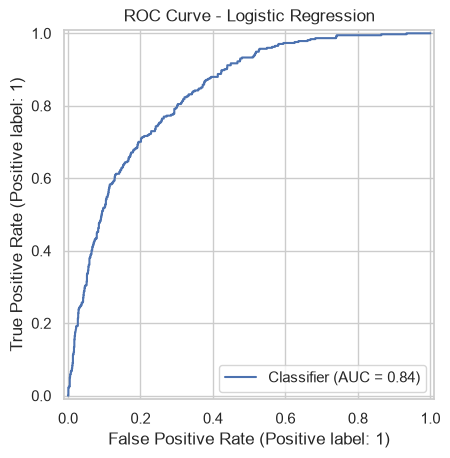

In [285]:
RocCurveDisplay.from_predictions(
    y_test,
    logistic_probabilities,
)
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [286]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)


In [287]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [288]:
rf_predictions = rf_model.predict(X_test)

In [289]:
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

In [290]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions,
    rf_probabilities
)


===== Random Forest =====
Accuracy : 0.7605
Precision: 0.5414
Recall   : 0.6471
F1 Score : 0.5895
ROC-AUC  : 0.8154


In [291]:
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1033
           1       0.54      0.65      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.78      0.76      0.77      1407



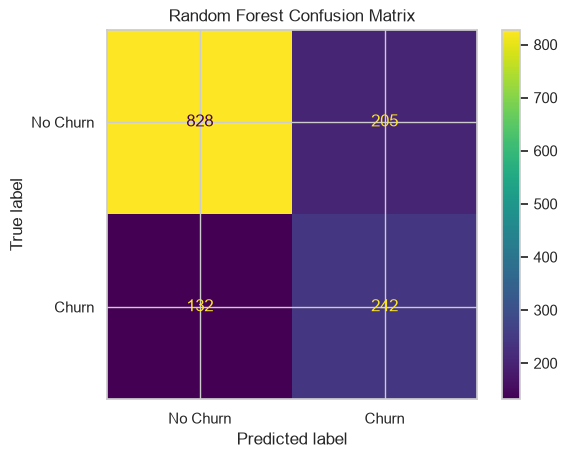

In [292]:
cm = confusion_matrix(
    y_test,
    rf_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [293]:
results = pd.DataFrame(
    [logistic_results, rf_results]
)
results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.725657,0.490132,0.796791,0.606925,0.835134
1,Random Forest,0.760483,0.541387,0.647059,0.589525,0.815362


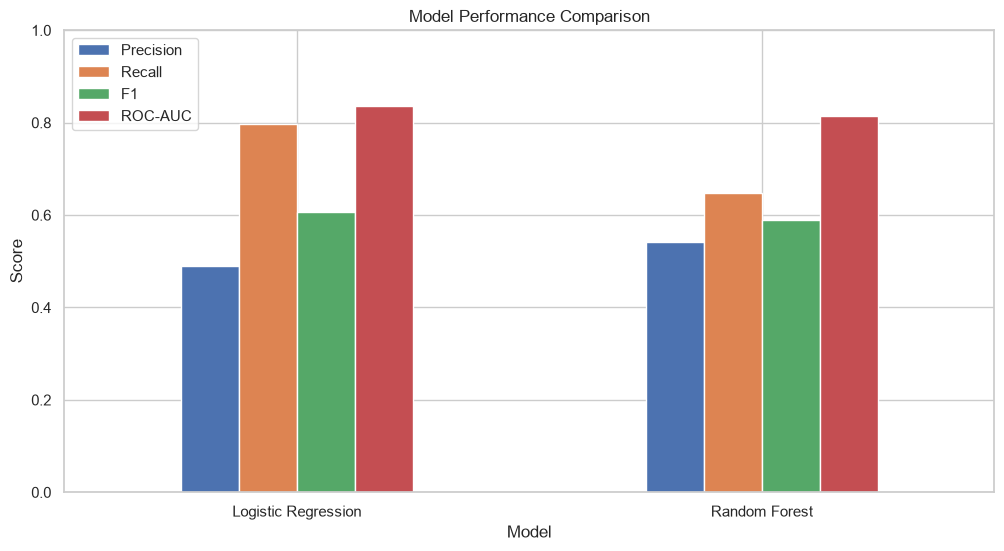

In [294]:
results.set_index(
    "Model"
)[
    [
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

The models were evaluated using accuracy, precision, recall,
F1-score and ROC-AUC because churn is an imbalanced
classification problem.

In [295]:
rf_probabilities[:10]

array([0.00666667, 0.85333333, 0.02333333, 0.13755556, 0.22333333,
       0.41333333, 0.04      , 0.365     , 0.87      , 0.01333333])

In [296]:
threshold_results = []

for threshold in np.arange(0.1, 1.0, 0.5):
    predictions = (rf_probabilities >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
    })
    
    threshold_df = pd.DataFrame(threshold_results)  
    
    threshold_df.head()

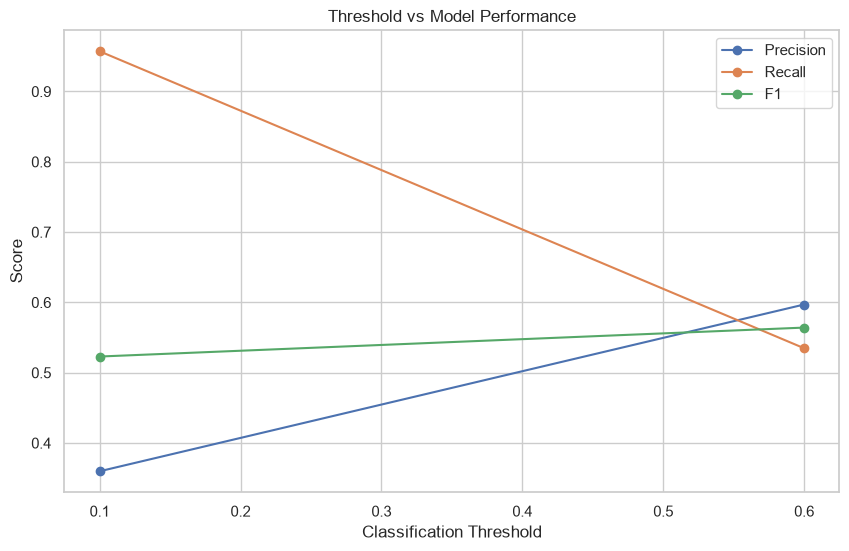

In [297]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")

plt.ylabel("Score")

plt.title("Threshold vs Model Performance")

plt.legend()

plt.show()

In [298]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold_row

Threshold    0.600000
Precision    0.597015
Recall       0.534759
F1           0.564175
Name: 1, dtype: float64

In [299]:
best_threshold = float(
    best_threshold_row["Threshold"]
)

best_threshold

0.6

In [300]:
final_predictions = (
    rf_probabilities >= best_threshold
).astype(int)

In [301]:
print(
    classification_report(
        y_test,
        final_predictions
    )
)

              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1033
           1       0.60      0.53      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



In [302]:
preprocessor_fitted = (
    rf_model
    .named_steps["preprocessor"]
)

In [303]:
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

In [304]:
rf_classifier = (
    rf_model
    .named_steps["classifier"]
)

In [305]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

In [306]:
feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

In [307]:
feature_importance.head(20)

,Feature,Importance
3,num__TotalCharges,0.141034
1,num__tenure,0.132027
2,num__MonthlyCharges,0.121903
36,cat__Contract_Month-to-month,0.076521
18,cat__OnlineSecurity_No,0.037804
38,cat__Contract_Two year,0.035473
27,cat__TechSupport_No,0.030841
43,cat__PaymentMethod_Electronic check,0.028448
16,cat__InternetService_Fiber optic,0.026967
21,cat__OnlineBackup_No,0.017953


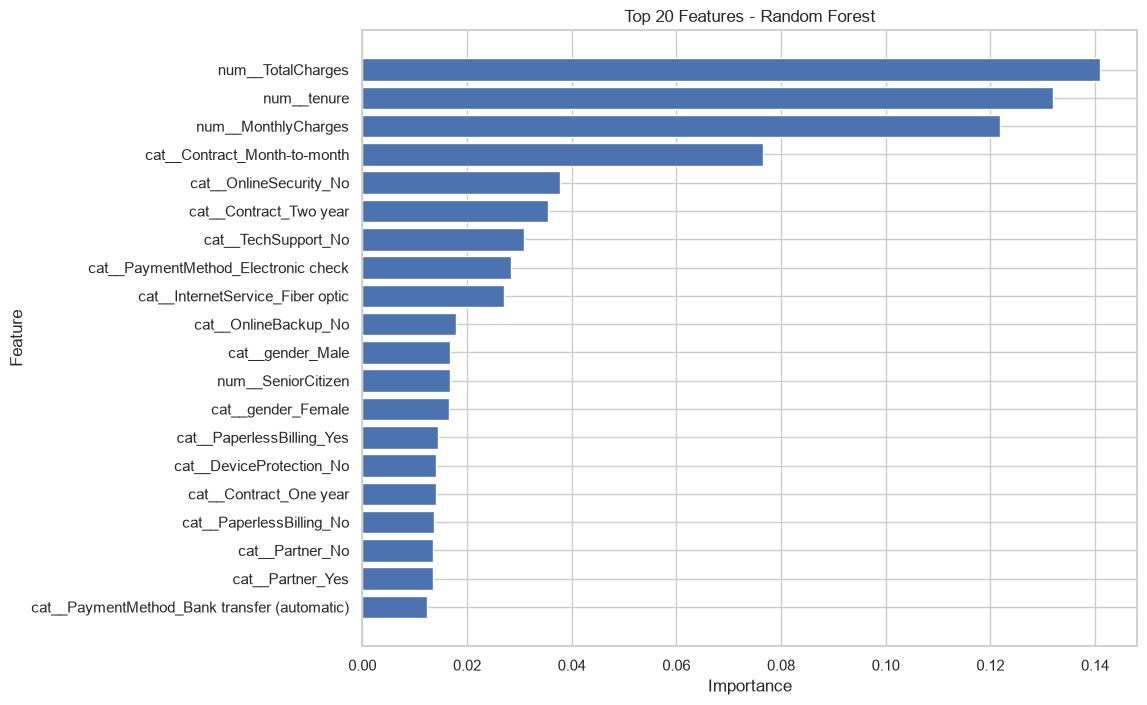

In [308]:
plt.figure(figsize=(10, 8))

top_features = (
    feature_importance
    .head(20)
    .sort_values("Importance")
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title(
    "Top 20 Features - Random Forest"
)

plt.show()

In [309]:
final_model = rf_model

In [310]:
joblib.dump(
    final_model,
    "../models/customer_churn_model.pkl"
)

['../models/customer_churn_model.pkl']

In [311]:
import json

with open(
    "../models/threshold.json",
    "w"
) as f:

    json.dump(
        {
            "threshold": best_threshold
        },
        f
    )

### Load the saved model


In [312]:
loaded_model = joblib.load(
    "../models/customer_churn_model.pkl"
)

In [313]:
loaded_probabilities = (
    loaded_model
    .predict_proba(X_test)[:, 1]
)

In [314]:
loaded_probabilities[:10]

array([0.00666667, 0.85333333, 0.02333333, 0.13755556, 0.22333333,
       0.41333333, 0.04      , 0.365     , 0.87      , 0.01333333])

In [315]:
new_customer = pd.DataFrame([
    {
        "customerID": "NEW001",
        "gender": "Female",
        "SeniorCitizen": 0,
        "Partner": "Yes",
        "Dependents": "No",
        "tenure": 5,
        "PhoneService": "Yes",
        "MultipleLines": "No",
        "InternetService": "Fiber optic",
        "OnlineSecurity": "No",
        "OnlineBackup": "No",
        "DeviceProtection": "No",
        "TechSupport": "No",
        "StreamingTV": "Yes",
        "StreamingMovies": "Yes",
        "Contract": "Month-to-month",
        "PaperlessBilling": "Yes",
        "PaymentMethod": "Electronic check",
        "MonthlyCharges": 90.0,
        "TotalCharges": 450.0
    }
])

In [316]:
probability = (
    loaded_model
    .predict_proba(new_customer)[0][1]
)

probability

np.float64(0.9066666666666666)

In [317]:
print(
    f"Churn probability: {probability * 100:.2f}%"
)

Churn probability: 90.67%


In [318]:
prediction = int(
    probability >= best_threshold
)

In [319]:
if prediction == 1:

    print("⚠️ Customer is likely to churn.")

else:

    print("✅ Customer is unlikely to churn.")

⚠️ Customer is likely to churn.


In [320]:
def predict_customer_churn(customer_data):
    
    customer_df = pd.DataFrame([
        customer_data
    ])

    probability = (
        loaded_model
        .predict_proba(customer_df)[0][1]
    )

    prediction = int(
        probability >= best_threshold
    )

    return {
        "churn_probability": round(
            float(probability),
            4
        ),
        "churn_prediction": prediction,
        "status": (
            "Likely to churn"
            if prediction == 1
            else "Unlikely to churn"
        )
    }

In [321]:
customer = {
    "customerID": "NEW002",
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 2,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 95.0,
    "TotalCharges": 190.0
}

In [322]:
predict_customer_churn(customer)

{'churn_probability': 0.8033,
 'churn_prediction': 1,
 'status': 'Likely to churn'}

# Final Results

## Models Evaluated

1. Logistic Regression
2. Random Forest

## Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

## Additional Analysis

- Churn distribution
- Contract vs churn
- Internet service vs churn
- Payment method vs churn
- Feature importance
- Classification threshold tuning

## Final Model

Random Forest with preprocessing pipeline.

## Deployment

The trained model is saved as:

`models/customer_churn_model.pkl`

The classification threshold is saved as:

`models/threshold.json`

The saved model can be integrated into a FastAPI prediction service.